# Lab3 - Modelos de Regresión Lineal

###  Importación de Librerías

In [75]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from scipy.stats import skew, kurtosis, shapiro


pd.set_option('display.max_columns', 100)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

### Carga de Datos

In [76]:
train = pd.read_csv('data/train.csv')
test  = pd.read_csv('data/test.csv')

print(f'Train : {train.shape[0]:,} filas × {train.shape[1]} columnas')
print(f'Test  : {test.shape[0]:,} filas × {test.shape[1]} columnas')
train.head(3)

Train : 1,460 filas × 81 columnas
Test  : 1,459 filas × 80 columnas


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.00,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.00,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,"2,003.00",RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.00,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.00,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,"1,976.00",RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.00,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.00,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,"2,001.00",RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500


### Descripción de las Variables

El dataset cuenta con **81 variables**: 1 identificador (`Id`), 79 predictores y 1 variable respuesta (`SalePrice`).

### Clasificación por tipo

In [77]:
num_cols  = train.select_dtypes(include=[np.number]).columns.drop(['Id', 'SalePrice']).tolist()
cat_cols  = train.select_dtypes(include='object').columns.tolist()

print(f'Variables numéricas  : {len(num_cols)}')
print(f'Variables categóricas: {len(cat_cols)}')
print(f'Variable respuesta   : SalePrice\n')

Variables numéricas  : 36
Variables categóricas: 43
Variable respuesta   : SalePrice



### Análisis Exploratorio General

In [78]:
# Estadísticas descriptivas de variables numéricas
train[num_cols + ['SalePrice']].describe()

,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,TotRmsAbvGrd,Fireplaces,GarageYrBlt,GarageCars,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,"1,460.00","1,201.00","1,460.00","1,460.00","1,460.00","1,460.00","1,460.00","1,452.00","1,460.00","1,460.00","1,460.00","1,460.00","1,460.00","1,460.00","1,460.00","1,460.00","1,460.00","1,460.00","1,460.00","1,460.00","1,460.00","1,460.00","1,460.00","1,460.00","1,379.00","1,460.00","1,460.00","1,460.00","1,460.00","1,460.00","1,460.00","1,460.00","1,460.00","1,460.00","1,460.00","1,460.00","1,460.00"
mean,56.90,70.05,"10,516.83",6.10,5.58,"1,971.27","1,984.87",103.69,443.64,46.55,567.24,"1,057.43","1,162.63",346.99,5.84,"1,515.46",0.43,0.06,1.57,0.38,2.87,1.05,6.52,0.61,"1,978.51",1.77,472.98,94.24,46.66,21.95,3.41,15.06,2.76,43.49,6.32,"2,007.82","180,921.20"
std,42.30,24.28,"9,981.26",1.38,1.11,30.20,20.65,181.07,456.10,161.32,441.87,438.71,386.59,436.53,48.62,525.48,0.52,0.24,0.55,0.50,0.82,0.22,1.63,0.64,24.69,0.75,213.80,125.34,66.26,61.12,29.32,55.76,40.18,496.12,2.70,1.33,"79,442.50"
min,20.00,21.00,"1,300.00",1.00,1.00,"1,872.00","1,950.00",0.00,0.00,0.00,0.00,0.00,334.00,0.00,0.00,334.00,0.00,0.00,0.00,0.00,0.00,0.00,2.00,0.00,"1,900.00",0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,"2,006.00","34,900.00"
25%,20.00,59.00,"7,553.50",5.00,5.00,"1,954.00","1,967.00",0.00,0.00,0.00,223.00,795.75,882.00,0.00,0.00,"1,129.50",0.00,0.00,1.00,0.00,2.00,1.00,5.00,0.00,"1,961.00",1.00,334.50,0.00,0.00,0.00,0.00,0.00,0.00,0.00,5.00,"2,007.00","129,975.00"
50%,50.00,69.00,"9,478.50",6.00,5.00,"1,973.00","1,994.00",0.00,383.50,0.00,477.50,991.50,"1,087.00",0.00,0.00,"1,464.00",0.00,0.00,2.00,0.00,3.00,1.00,6.00,1.00,"1,980.00",2.00,480.00,0.00,25.00,0.00,0.00,0.00,0.00,0.00,6.00,"2,008.00","163,000.00"
75%,70.00,80.00,"11,601.50",7.00,6.00,"2,000.00","2,004.00",166.00,712.25,0.00,808.00,"1,298.25","1,391.25",728.00,0.00,"1,776.75",1.00,0.00,2.00,1.00,3.00,1.00,7.00,1.00,"2,002.00",2.00,576.00,168.00,68.00,0.00,0.00,0.00,0.00,0.00,8.00,"2,009.00","214,000.00"
max,190.00,313.00,"215,245.00",10.00,9.00,"2,010.00","2,010.00","1,600.00","5,644.00","1,474.00","2,336.00","6,110.00","4,692.00","2,065.00",572.00,"5,642.00",3.00,2.00,3.00,2.00,8.00,3.00,14.00,3.00,"2,010.00",4.00,"1,418.00",857.00,547.00,552.00,508.00,480.00,738.00,"15,500.00",12.00,"2,010.00","755,000.00"


In [79]:
# Resumen de variables categóricas
cat_summary = pd.DataFrame({
    'Valores únicos' : train[cat_cols].nunique(),
    'Moda'           : train[cat_cols].mode().iloc[0],
    'Frec. moda (%)'  : (train[cat_cols].apply(lambda c: c.value_counts(normalize=True).iloc[0]) * 100).round(1),
    'Nulos (%)'      : (train[cat_cols].isnull().mean() * 100).round(1)
})
cat_summary.sort_values('Nulos (%)', ascending=False)

,Valores únicos,Moda,Frec. moda (%),Nulos (%)
PoolQC,3,Gd,42.90,99.50
MiscFeature,4,Shed,90.70,96.30
Alley,2,Grvl,54.90,93.80
Fence,4,MnPrv,55.90,80.80
MasVnrType,3,BrkFace,75.70,59.70
FireplaceQu,5,Gd,49.40,47.30
GarageFinish,3,Unf,43.90,5.50
GarageQual,5,TA,95.10,5.50
GarageType,6,Attchd,63.10,5.50
GarageCond,5,TA,96.20,5.50


### Variable Respuesta: SalePrice

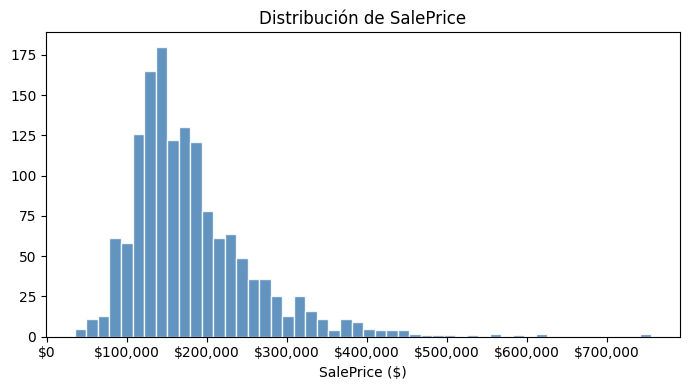

In [80]:
sp = train['SalePrice']

fig, ax = plt.subplots(figsize=(7, 4))

ax.hist(sp, bins=50, color='steelblue', edgecolor='white', alpha=0.85)
ax.set_title('Distribución de SalePrice')
ax.set_xlabel('SalePrice ($)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

plt.tight_layout()
plt.show()

### Distribución de Variables Numéricas

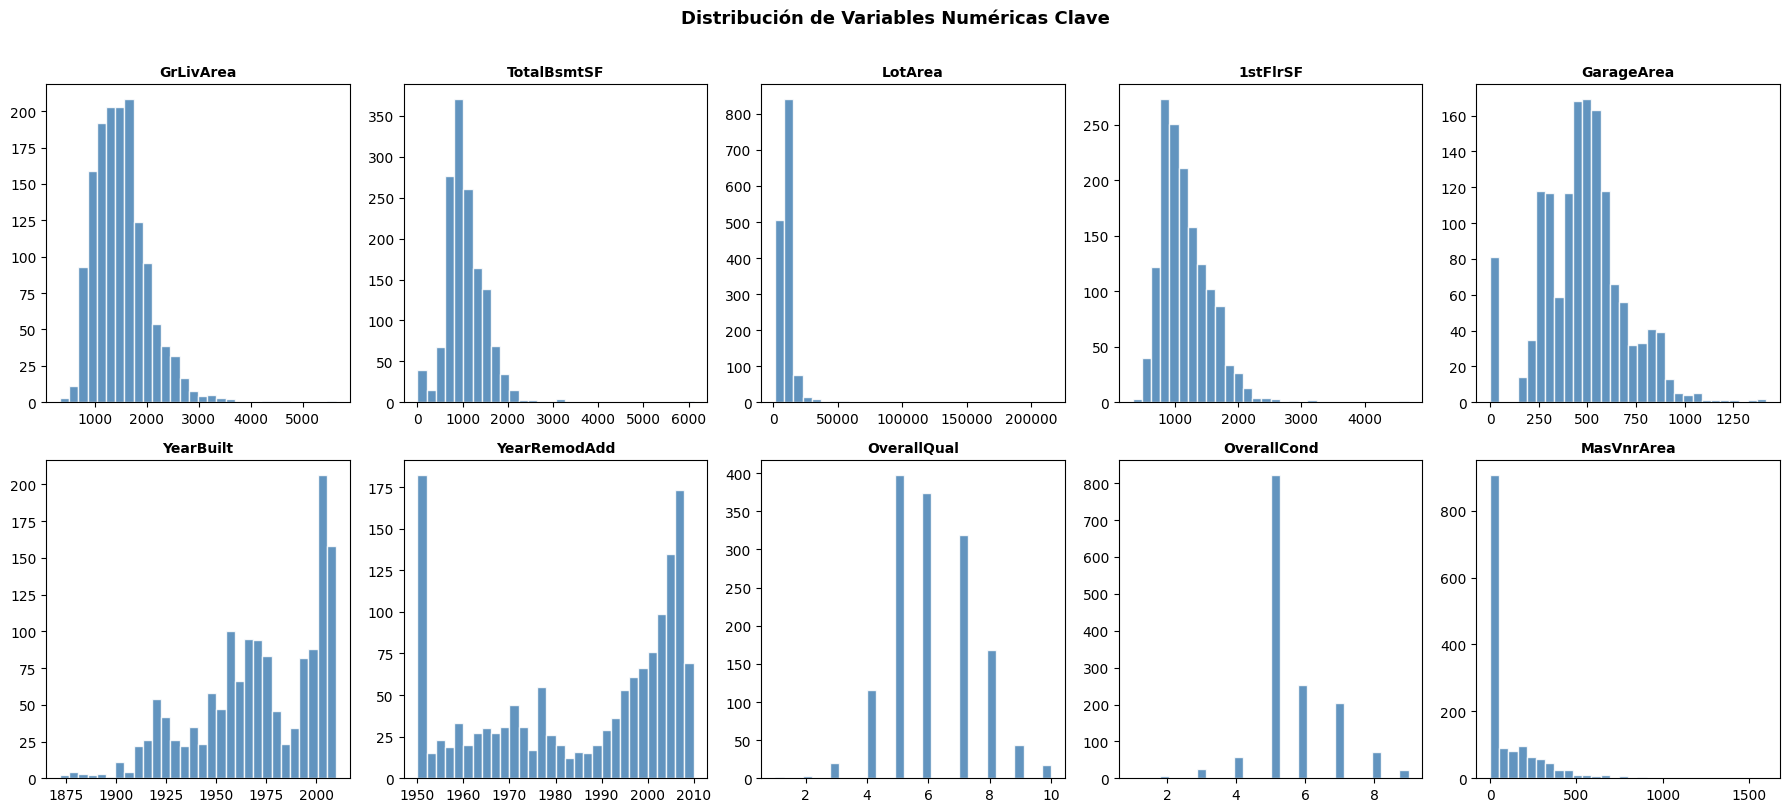

In [81]:
# Histogramas de las variables numéricas más importantes
key_num = ['GrLivArea', 'TotalBsmtSF', 'LotArea', '1stFlrSF', 'GarageArea',
           'YearBuilt', 'YearRemodAdd', 'OverallQual', 'OverallCond', 'MasVnrArea']

fig, axes = plt.subplots(2, 5, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(key_num):
    axes[i].hist(train[col].dropna(), bins=30, color='steelblue', edgecolor='white', alpha=0.85)
    axes[i].set_title(col, fontsize=10, fontweight='bold')
    axes[i].set_xlabel('')

plt.suptitle('Distribución de Variables Numéricas Clave', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### Distribución de Variables Categóricas

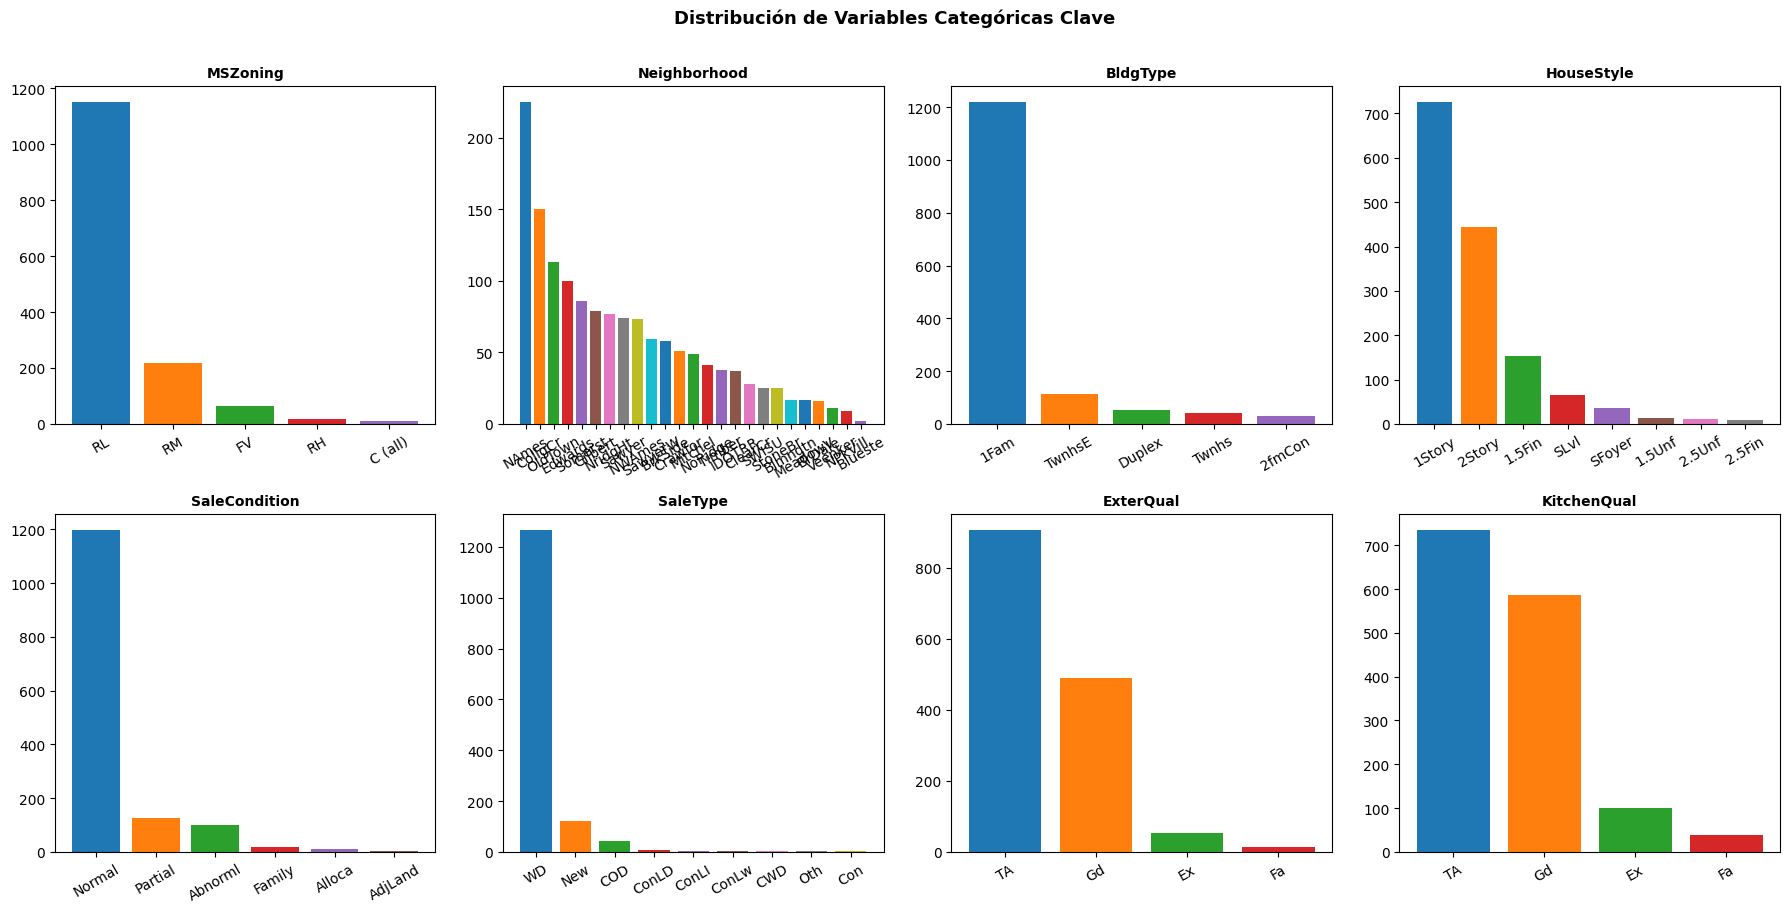

In [82]:
# Frecuencias de las principales variables categóricas
key_cat = ['MSZoning', 'Neighborhood', 'BldgType', 'HouseStyle',
           'SaleCondition', 'SaleType', 'ExterQual', 'KitchenQual']

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()

for i, col in enumerate(key_cat):
    counts = train[col].value_counts()
    axes[i].bar(counts.index, counts.values,
                color=sns.color_palette('tab10', len(counts)))
    axes[i].set_title(col, fontsize=10, fontweight='bold')
    axes[i].tick_params(axis='x', rotation=30)

plt.suptitle('Distribución de Variables Categóricas Clave', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### Análisis de Correlaciones (Variables Numéricas)

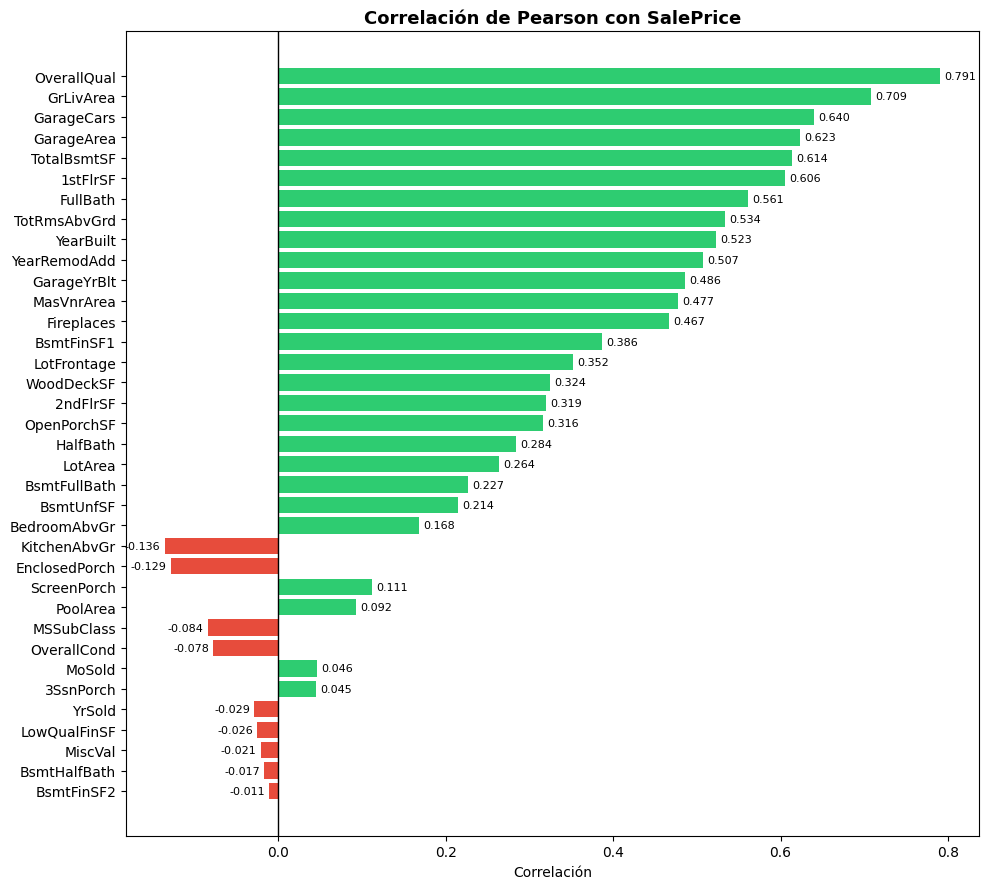

In [83]:
# Top correlaciones con SalePrice
corr_with_target = (
    train[num_cols + ['SalePrice']]
    .corr()['SalePrice']
    .drop('SalePrice')
    .sort_values(key=abs, ascending=False)
)

fig, ax = plt.subplots(figsize=(10, 9))
colors = ['#2ecc71' if v > 0 else '#e74c3c' for v in corr_with_target]
bars = ax.barh(corr_with_target.index, corr_with_target.values, color=colors)
ax.axvline(0, color='black', lw=1)
ax.set_title('Correlación de Pearson con SalePrice', fontsize=13, fontweight='bold')
ax.set_xlabel('Correlación')
ax.bar_label(bars, fmt='%.3f', padding=3, fontsize=8)
ax.invert_yaxis()
plt.tight_layout()
plt.show()


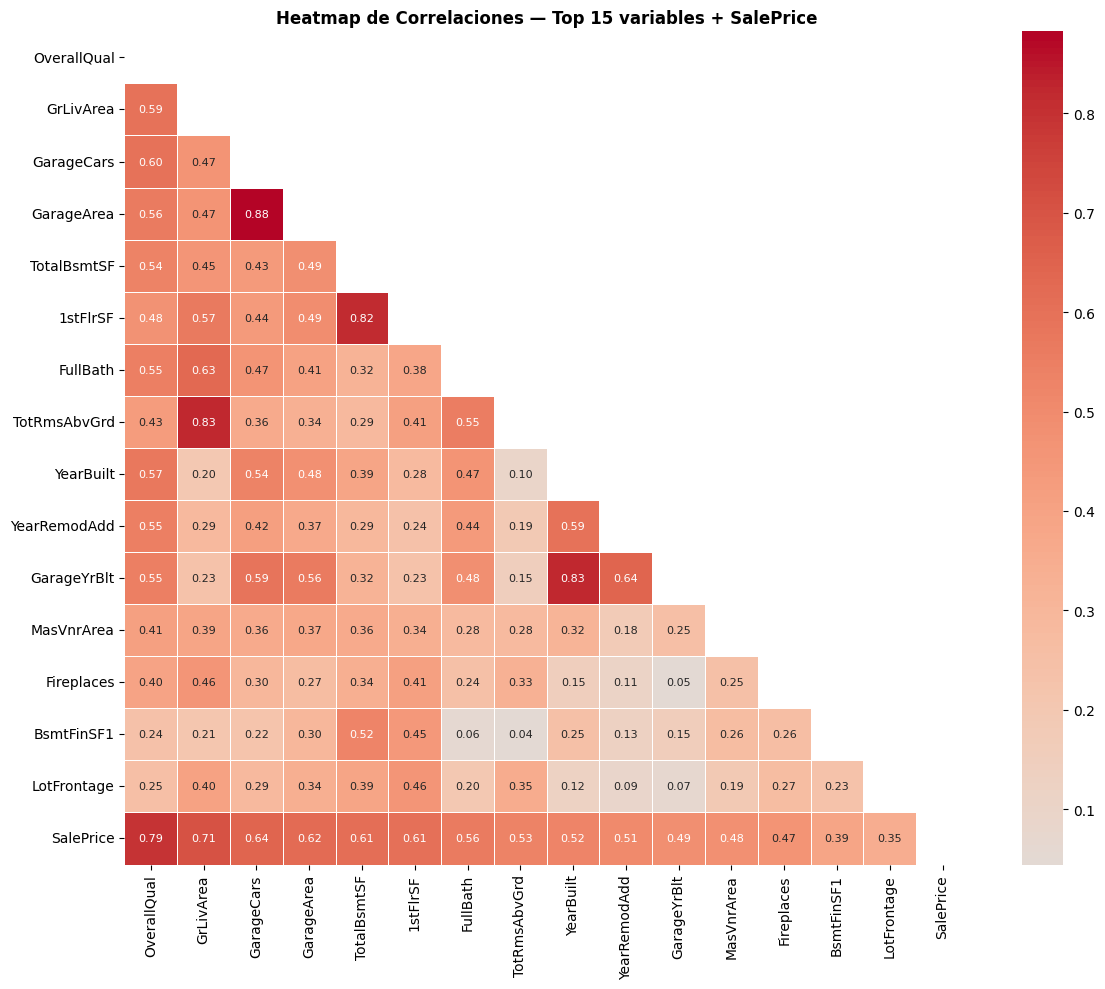

In [84]:
# Heatmap de correlaciones — Top 15 variables
top15 = corr_with_target.head(15).index.tolist() + ['SalePrice']
corr_matrix = train[top15].corr()

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f',
    cmap='coolwarm', center=0, linewidths=0.5,
    annot_kws={'size': 8}, ax=ax
)
ax.set_title('Heatmap de Correlaciones — Top 15 variables + SalePrice', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

### Relaciones Numéricas con SalePrice

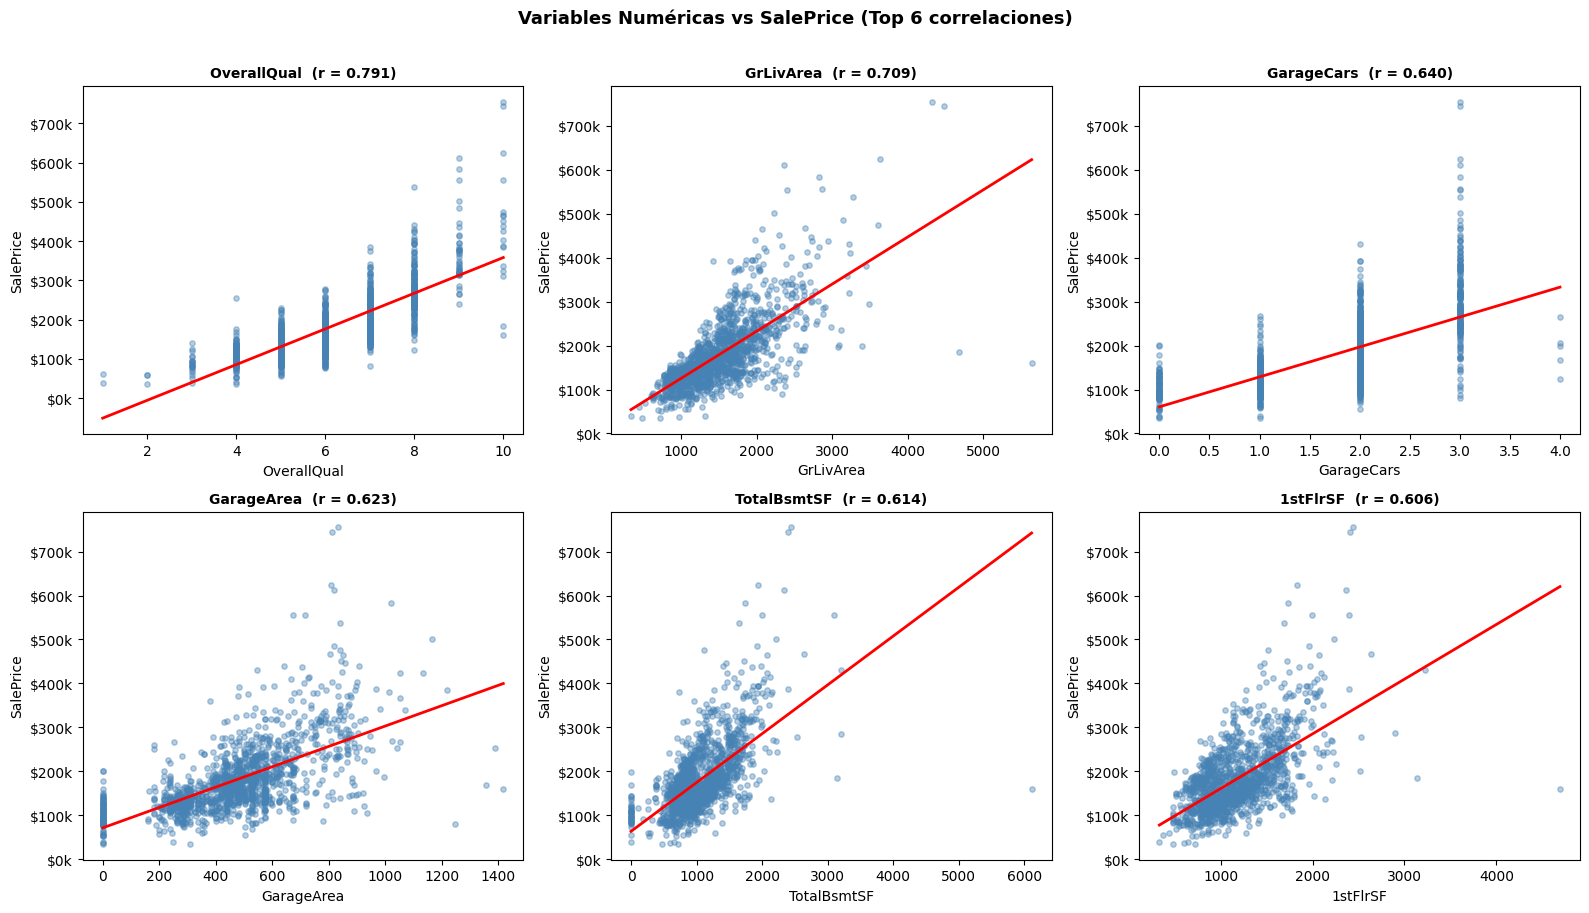

In [85]:
# Scatter plots: top 6 variables numéricas vs SalePrice
top6_num = corr_with_target.head(6).index.tolist()

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, col in enumerate(top6_num):
    x = train[col]
    y = train['SalePrice']
    valid = x.notna() & y.notna()
    axes[i].scatter(x[valid], y[valid], alpha=0.4, s=15, color='steelblue')
    # Línea de tendencia
    m, b = np.polyfit(x[valid], y[valid], 1)
    xline = np.linspace(x[valid].min(), x[valid].max(), 200)
    axes[i].plot(xline, m * xline + b, color='red', lw=2)
    r = np.corrcoef(x[valid], y[valid])[0, 1]
    axes[i].set_title(f'{col}  (r = {r:.3f})', fontsize=10, fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('SalePrice')
    axes[i].yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'${v/1e3:.0f}k'))

plt.suptitle('Variables Numéricas vs SalePrice (Top 6 correlaciones)', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

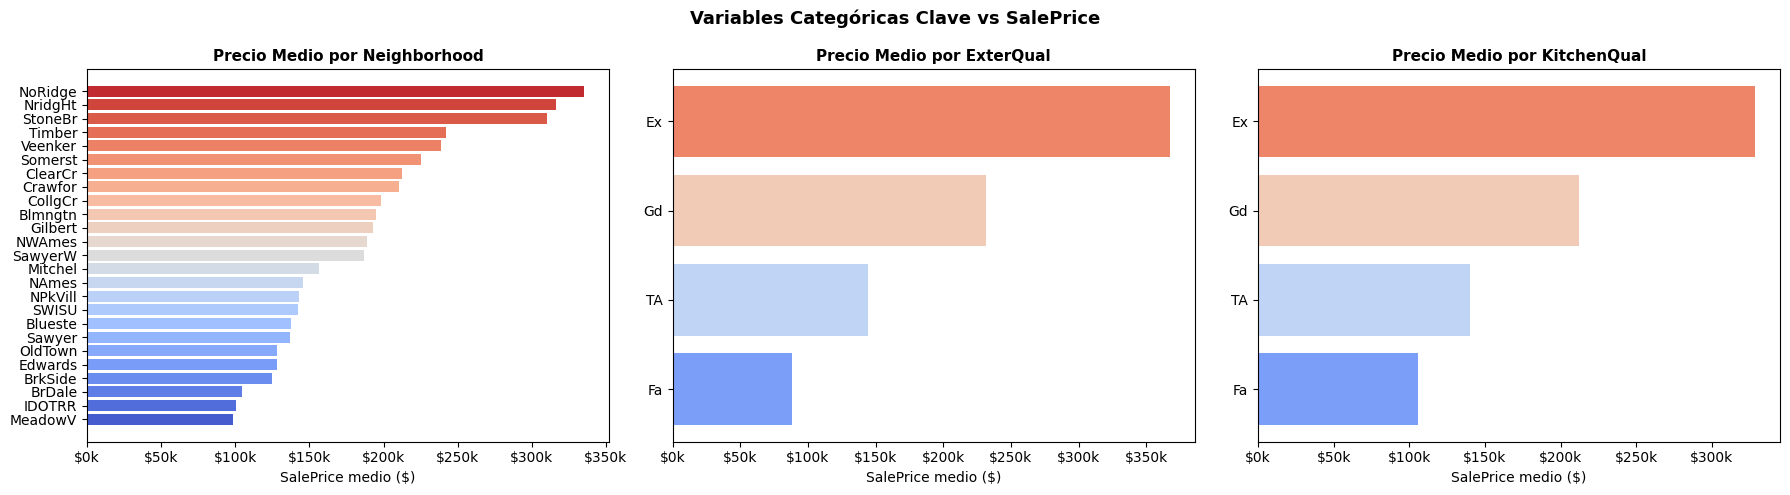

In [86]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

cat_vars = ['Neighborhood', 'ExterQual', 'KitchenQual']

for i, col in enumerate(cat_vars):
    means = train.groupby(col)['SalePrice'].mean().sort_values(ascending=True)
    axes[i].barh(means.index, means.values, color=sns.color_palette('coolwarm', len(means)))
    axes[i].set_title(f'Precio Medio por {col}', fontsize=11, fontweight='bold')
    axes[i].set_xlabel('SalePrice medio ($)')
    axes[i].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e3:.0f}k'))

plt.suptitle('Variables Categóricas Clave vs SalePrice', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [87]:
sp = train['SalePrice']

# --- Variables a eliminar por nulos excesivos (>15%) ---
thresh = 0.15
cols_drop_missing = [c for c in train.columns 
                     if train[c].isnull().mean() > thresh]

# --- Variables a conservar por correlación con SalePrice ---
# Solo numéricas, umbral |r| > 0.3
corr_with_target = (
    train[num_cols + ['SalePrice']]
    .corr()['SalePrice']
    .drop('SalePrice')
)
cols_keep = corr_with_target[abs(corr_with_target) >= 0.3].index.tolist()

# --- Variables finales ---
cols_drop_lowcorr = [c for c in num_cols if c not in cols_keep]


print("   HALLAZGOS Y PASOS PARA EL PREPROCESAMIENTO")
print("-" * 80)

print(f"\n COLUMNAS A ELIMINAR por nulos > 15%: {len(cols_drop_missing)}")
for c in cols_drop_missing:
    pct = train[c].isnull().mean() * 100
    print(f"    {c:<20} ({pct:.1f}% nulos)")

print(f"\n COLUMNAS NUMERICAS A ELIMINAR por baja correlacion |r| < 0.3: {len(cols_drop_lowcorr)}")
for c in cols_drop_lowcorr:
    print(f"    {c:<20} (r = {corr_with_target[c]:.3f})")

print(f"\n VARIABLES NUMERICAS UTILES PARA EL MODELO: {len(cols_keep)}")
for c in sorted(cols_keep, key=lambda x: abs(corr_with_target[x]), reverse=True):
    print(f"    {c:<20} (r = {corr_with_target[c]:.3f})")

print("""
 PASOS FUTUROS
  1. Eliminar columnas con >15% de nulos
  2. Eliminar filas restantes con NAs (dropna)
  3. Quedarse solo con variables numericas utiles (|r| >= 0.3)
  4. Separar variable respuesta: y = SalePrice, X = predictores
  5. train_test_split (70% train / 30% test)
  6. Entrenar modelo lineal multiple (OLS)
  7. Evaluar: R2, MAE, MSE, RMSE
  8. Analisis de residuos (scatter + QQ plot + Lilliefors)
  9. Comparar con Ridge y Lasso si hay multicolinealidad
""")

   HALLAZGOS Y PASOS PARA EL PREPROCESAMIENTO
--------------------------------------------------------------------------------

 COLUMNAS A ELIMINAR por nulos > 15%: 7
    LotFrontage          (17.7% nulos)
    Alley                (93.8% nulos)
    MasVnrType           (59.7% nulos)
    FireplaceQu          (47.3% nulos)
    PoolQC               (99.5% nulos)
    Fence                (80.8% nulos)
    MiscFeature          (96.3% nulos)

 COLUMNAS NUMERICAS A ELIMINAR por baja correlacion |r| < 0.3: 18
    MSSubClass           (r = -0.084)
    LotArea              (r = 0.264)
    OverallCond          (r = -0.078)
    BsmtFinSF2           (r = -0.011)
    BsmtUnfSF            (r = 0.214)
    LowQualFinSF         (r = -0.026)
    BsmtFullBath         (r = 0.227)
    BsmtHalfBath         (r = -0.017)
    HalfBath             (r = 0.284)
    BedroomAbvGr         (r = 0.168)
    KitchenAbvGr         (r = -0.136)
    EnclosedPorch        (r = -0.129)
    3SsnPorch            (r = 0.045)
    

## Parte 2

In [88]:
# ── Preprocesamiento ──────────────────────────────────────────

cols_none = ['PoolQC','MiscFeature','Alley','Fence','FireplaceQu',
             'GarageType','GarageFinish','GarageQual','GarageCond',
             'BsmtQual','BsmtCond','BsmtExposure','BsmtFinType1','BsmtFinType2',
             'MasVnrType']
train[cols_none] = train[cols_none].fillna('None')


cols_zero = ['GarageYrBlt','GarageArea','GarageCars',
             'BsmtFinSF1','BsmtFinSF2','BsmtUnfSF','TotalBsmtSF',
             'BsmtFullBath','BsmtHalfBath','MasVnrArea']
train[cols_zero] = train[cols_zero].fillna(0)


train['LotFrontage'] = train.groupby('Neighborhood')['LotFrontage']\
                            .transform(lambda x: x.fillna(x.median()))

for col in train[num_cols].columns[train[num_cols].isnull().any()]:
    train[col] = train[col].fillna(train[col].median())

print("Nulos restantes:", train.isnull().sum().sum())

Nulos restantes: 1


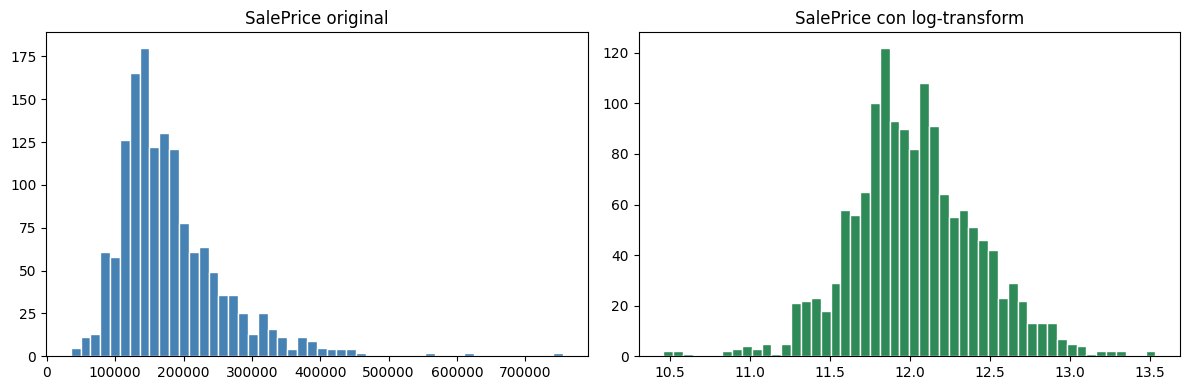

In [89]:
import numpy as np


train['SalePrice_log'] = np.log1p(train['SalePrice'])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(train['SalePrice'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('SalePrice original')
axes[1].hist(train['SalePrice_log'], bins=50, color='seagreen', edgecolor='white')
axes[1].set_title('SalePrice con log-transform')
plt.tight_layout()
plt.show()

In [90]:
from sklearn.preprocessing import StandardScaler

# Eliminar los 2 outliers sospechosos que encontramos
train = train.drop(train[(train['GrLivArea'] > 4000) & 
                          (train['SalePrice'] < 300000)].index)

# Variables seleccionadas (evitando multicolinealidad)
# Quitamos GarageArea (redundante con GarageCars)
# Quitamos TotRmsAbvGrd (redundante con GrLivArea)
# Quitamos GarageYrBlt (redundante con YearBuilt)
# Quitamos 1stFlrSF (redundante con TotalBsmtSF)
features = ['OverallQual', 'GrLivArea', 'GarageCars',
            'TotalBsmtSF', 'FullBath', 'YearBuilt',
            'YearRemodAdd', 'MasVnrArea', 'Fireplaces', 'LotFrontage']

X = train[features].copy()
y = train['SalePrice_log'].copy()

# Escalar variables
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=features, index=X.index)

print(f"Shape final: {X_scaled.shape}")
print(f"Variables usadas: {features}")

Shape final: (1458, 10)
Variables usadas: ['OverallQual', 'GrLivArea', 'GarageCars', 'TotalBsmtSF', 'FullBath', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'Fireplaces', 'LotFrontage']


In [91]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, 
    test_size=0.20,      # 80% entrena, 20% prueba
    random_state=42      # semilla fija → resultados reproducibles
)

print(f"Entrenamiento : {X_train.shape[0]} filas")
print(f"Prueba        : {X_test.shape[0]} filas")

Entrenamiento : 1166 filas
Prueba        : 292 filas


In [92]:
try:
    import statsmodels.api as sm
except ModuleNotFoundError:
    %pip install -q statsmodels
    import statsmodels.api as sm

# OLS necesita que agreguemos la constante manualmente
X_train_ols = sm.add_constant(X_train)
X_test_ols  = sm.add_constant(X_test)

modelo_ols = sm.OLS(y_train, X_train_ols).fit()
print(modelo_ols.summary())

                            OLS Regression Results                            
Dep. Variable:          SalePrice_log   R-squared:                       0.870
Model:                            OLS   Adj. R-squared:                  0.869
Method:                 Least Squares   F-statistic:                     774.6
Date:                Sun, 15 Mar 2026   Prob (F-statistic):               0.00
Time:                        23:29:11   Log-Likelihood:                 613.87
No. Observations:                1166   AIC:                            -1206.
Df Residuals:                    1155   BIC:                            -1150.
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const           12.0259      0.004   2858.513   

In [93]:
from sklearn.linear_model import Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Ridge
modelo_ridge = Ridge(alpha=10, random_state=42)
modelo_ridge.fit(X_train, y_train)

# Lasso
modelo_lasso = Lasso(alpha=0.001, random_state=42)
modelo_lasso.fit(X_train, y_train)

# Predicciones en train
pred_ols_train   = modelo_ols.predict(X_train_ols)
pred_ridge_train = modelo_ridge.predict(X_train)
pred_lasso_train = modelo_lasso.predict(X_train)

print("── Resultados en ENTRENAMIENTO ──")
for nombre, pred in [('OLS', pred_ols_train), ('Ridge', pred_ridge_train), ('Lasso', pred_lasso_train)]:
    rmse = np.sqrt(mean_squared_error(y_train, pred))
    r2   = r2_score(y_train, pred)
    print(f"{nombre:6s} → RMSE: {rmse:.4f} | R²: {r2:.4f}")

── Resultados en ENTRENAMIENTO ──
OLS    → RMSE: 0.1429 | R²: 0.8702
Ridge  → RMSE: 0.1429 | R²: 0.8702
Lasso  → RMSE: 0.1430 | R²: 0.8702


OLS — Lilliefors: stat=0.0589, p=0.0010 → NO normal
Ridge — Lilliefors: stat=0.0603, p=0.0010 → NO normal
Lasso — Lilliefors: stat=0.0619, p=0.0010 → NO normal


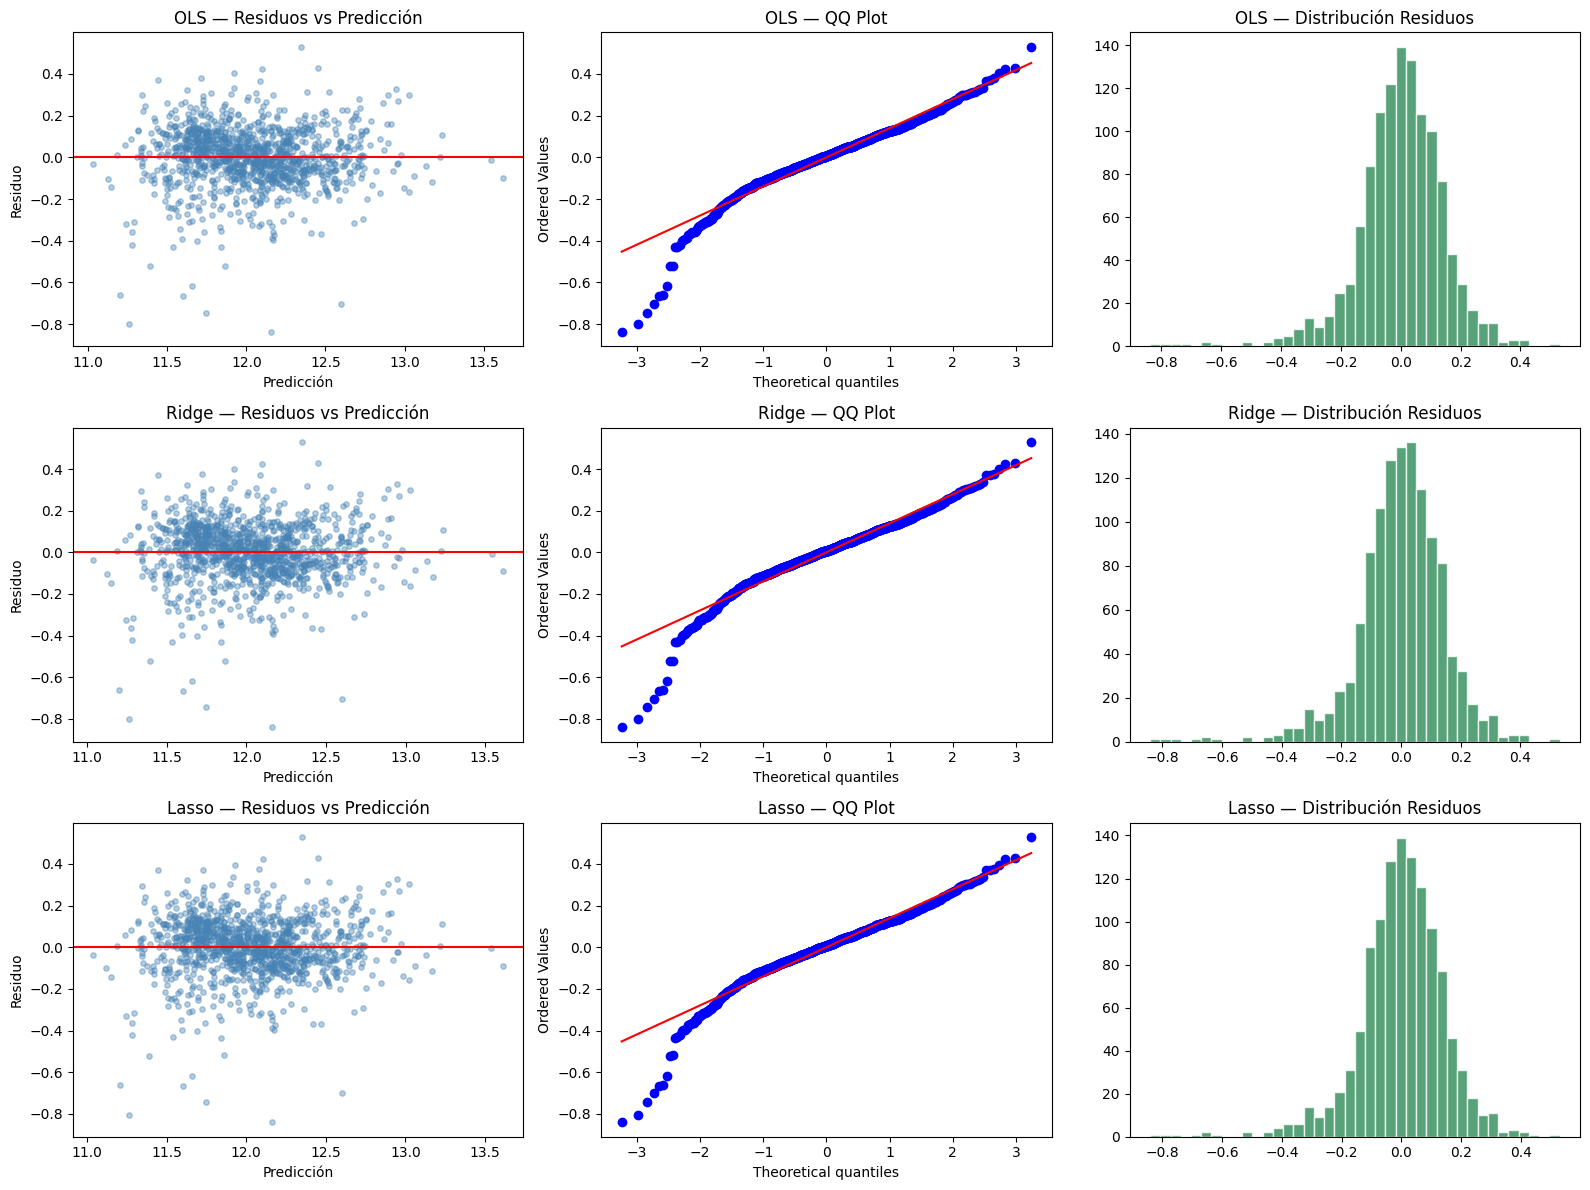

In [94]:
from scipy import stats
from statsmodels.stats.diagnostic import lilliefors

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
modelos_info = [
    ('OLS',   y_train.values, pred_ols_train),
    ('Ridge', y_train.values, pred_ridge_train),
    ('Lasso', y_train.values, pred_lasso_train),
]

for i, (nombre, y_real, y_pred) in enumerate(modelos_info):
    residuos = y_real - y_pred

    # Scatter de residuos
    axes[i,0].scatter(y_pred, residuos, alpha=0.4, color='steelblue', s=15)
    axes[i,0].axhline(0, color='red', linewidth=1.5)
    axes[i,0].set_title(f'{nombre} — Residuos vs Predicción')
    axes[i,0].set_xlabel('Predicción'); axes[i,0].set_ylabel('Residuo')

    # QQ plot
    stats.probplot(residuos, dist="norm", plot=axes[i,1])
    axes[i,1].set_title(f'{nombre} — QQ Plot')

    # Histograma de residuos
    axes[i,2].hist(residuos, bins=40, color='seagreen', edgecolor='white', alpha=0.8)
    axes[i,2].set_title(f'{nombre} — Distribución Residuos')

    # Lilliefors
    stat, p = lilliefors(residuos)
    print(f"{nombre} — Lilliefors: stat={stat:.4f}, p={p:.4f} → {'NO normal' if p < 0.05 else 'Normal'}")

plt.tight_layout()
plt.show()

── Resultados en PRUEBA ──
OLS    → RMSE: 0.1551 | R²: 0.8573 | MAE: 0.1127
Ridge  → RMSE: 0.1551 | R²: 0.8572 | MAE: 0.1127
Lasso  → RMSE: 0.1551 | R²: 0.8573 | MAE: 0.1128


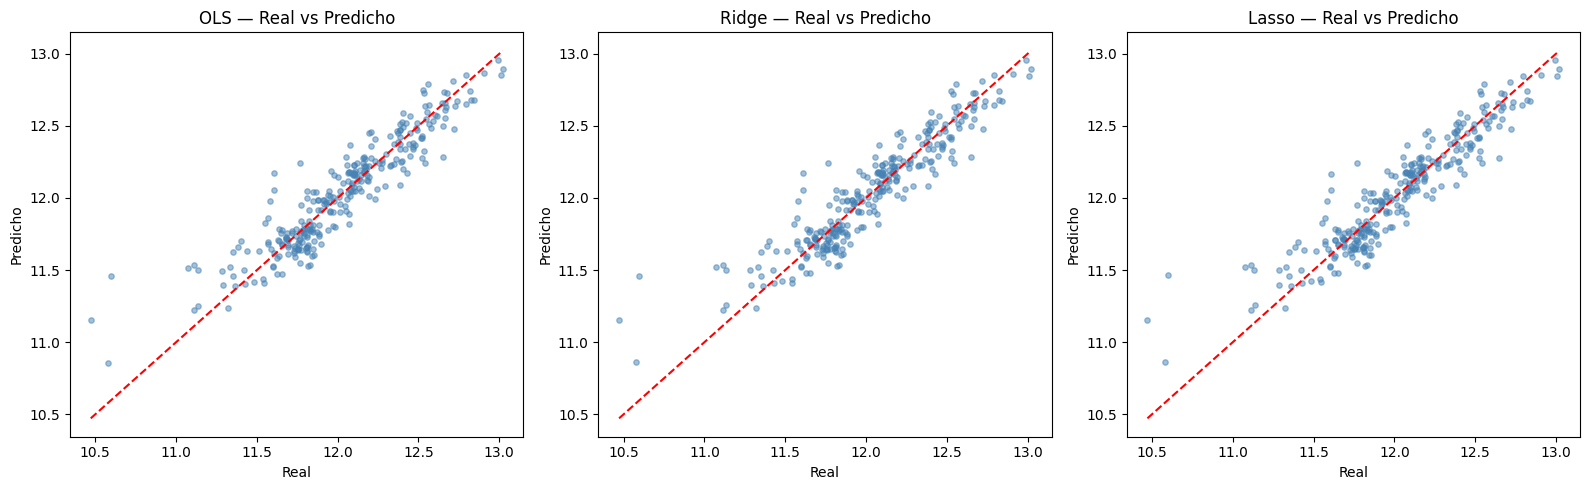

In [95]:
# Predicciones en TEST
pred_ols_test   = modelo_ols.predict(X_test_ols)
pred_ridge_test = modelo_ridge.predict(X_test)
pred_lasso_test = modelo_lasso.predict(X_test)

print("── Resultados en PRUEBA ──")
for nombre, pred in [('OLS', pred_ols_test), ('Ridge', pred_ridge_test), ('Lasso', pred_lasso_test)]:
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    r2   = r2_score(y_test, pred)
    mae  = np.mean(np.abs(y_test - pred))
    print(f"{nombre:6s} → RMSE: {rmse:.4f} | R²: {r2:.4f} | MAE: {mae:.4f}")

# Gráfica predicho vs real
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for i, (nombre, pred) in enumerate([('OLS', pred_ols_test), ('Ridge', pred_ridge_test), ('Lasso', pred_lasso_test)]):
    axes[i].scatter(y_test, pred, alpha=0.5, color='steelblue', s=15)
    axes[i].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=1.5)
    axes[i].set_title(f'{nombre} — Real vs Predicho')
    axes[i].set_xlabel('Real'); axes[i].set_ylabel('Predicho')
plt.tight_layout()
plt.show()

In [96]:
modelos = {
    "OLS": pred_ols_test,
    "Ridge": pred_ridge_test,
    "Lasso": pred_lasso_test
}

n = len(y_test)
k = X_test.shape[1]

resultados = []

for nombre, pred in modelos.items():
    
    mse = mean_squared_error(y_test, pred)
    rmse = np.sqrt(mse)
    mae = np.mean(np.abs(y_test - pred))
    r2 = r2_score(y_test, pred)

    # AIC y BIC
    aic = n * np.log(mse) + 2 * k
    bic = n * np.log(mse) + k * np.log(n)

    resultados.append([nombre, r2, mae, mse, rmse, aic, bic])

resultados_df = pd.DataFrame(
    resultados,
    columns=["Modelo", "R2", "MAE", "MSE", "RMSE", "AIC", "BIC"]
)

resultados_df

,Modelo,R2,MAE,MSE,RMSE,AIC,BIC
0,OLS,0.86,0.11,0.02,0.16,"-1,068.38","-1,031.61"
1,Ridge,0.86,0.11,0.02,0.16,"-1,068.25","-1,031.49"
2,Lasso,0.86,0.11,0.02,0.16,"-1,068.42","-1,031.65"


In [97]:
# --- Tabla comparativa ordenada por RMSE ---

resultados_df.sort_values("RMSE")

,Modelo,R2,MAE,MSE,RMSE,AIC,BIC
2,Lasso,0.86,0.11,0.02,0.16,"-1,068.42","-1,031.65"
0,OLS,0.86,0.11,0.02,0.16,"-1,068.38","-1,031.61"
1,Ridge,0.86,0.11,0.02,0.16,"-1,068.25","-1,031.49"


In [98]:
# --- Selección del mejor modelo ---

mejor_modelo = resultados_df.loc[resultados_df["RMSE"].idxmin()]

print("Mejor modelo según RMSE:")
print(mejor_modelo)

Mejor modelo según RMSE:
Modelo       Lasso
R2            0.86
MAE           0.11
MSE           0.02
RMSE          0.16
AIC      -1,068.42
BIC      -1,031.65
Name: 2, dtype: object


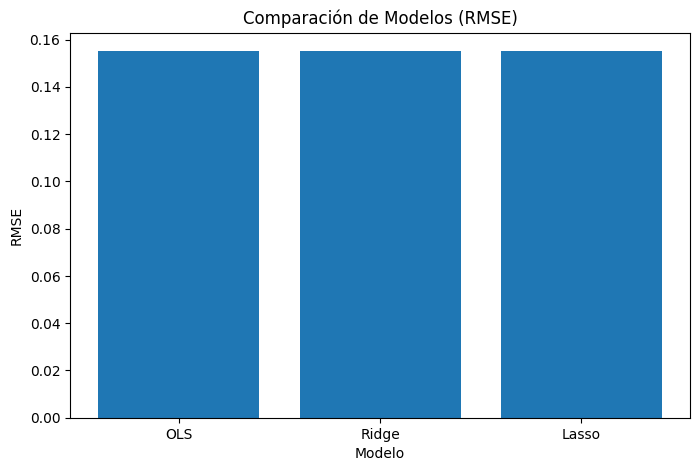

In [99]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(resultados_df["Modelo"], resultados_df["RMSE"])

plt.title("Comparación de Modelos (RMSE)")
plt.ylabel("RMSE")
plt.xlabel("Modelo")

plt.show()